# Project Title

 **Exploratory Data Analysis of Vehicle Records**

 # Project Objective


This project aims to explore and summarize a vehicle records dataset using exploratory data analysis techniques.The analysis focuses on understandng
the dataset's characteristics, evaluating data quality, examining the distribution of key vehicle attributes, identifying trends and relationships 
among variables, and presenting findings through appropriate statistical summaries and visualizations.

# Dataset Description


This dataset contains information about vehicles, including their  identification details, technical specifications, ownership information, and usage characteristics. It comprises variables such as vehicle make, model, manufacturing year, VIN, license plate number,	Owner details, mileage
fuel type, transmission type and color. The dataset is suitable for exploratory data analysis to examine vehicle characteristics, assess 
data quality and identify patterns within the records.

 # Environment Setup

In [1]:
# Standard library import
import os
import warnings

# Necessary data analysis libraries
import pandas as pd
import numpy as np

# Data visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

# Global configuration
warnings.filterwarnings('ignore')
%matplotlib inline

# Default Seaborn style and color palette
sns.set_theme(style = 'whitegrid')
sns.set_palette ('muted') 

# Default title and label font size for Matplotlib
plt.rcParams.update({'font.size': 10, 'axes.labelsize': 10, 'axes.titlesize': 14})

# Maximum column visibility
pd.set_option('display.max_columns', None)

# Data Loading 

In [2]:
# File path 
data_path = "data/vehicle_details.xlsx"

# Load dataset
df = pd.read_excel(data_path)

# Initial Inspection

In [3]:
# Data dimensions
print(f"Dataset Dimensions: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Inspect data
print('---------- Dataset Information ----------') 
df.info() 

# Data preview
df.tail()

Dataset Dimensions: 5000 rows, 12 columns

---------- Dataset Information ----------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Vehicle ID     5000 non-null   object
 1   Make           5000 non-null   object
 2   Model          5000 non-null   object
 3   Year           5000 non-null   int64 
 4   VIN            5000 non-null   object
 5   License Plate  5000 non-null   object
 6   Owner Name     5000 non-null   object
 7   Owner Contact  5000 non-null   object
 8   Mileage        5000 non-null   int64 
 9   Fuel Type      5000 non-null   object
 10  Transmission   5000 non-null   object
 11  Color          5000 non-null   object
dtypes: int64(2), object(10)
memory usage: 468.9+ KB


,Vehicle ID,Make,Model,Year,VIN,License Plate,Owner Name,Owner Contact,Mileage,Fuel Type,Transmission,Color
4995,6910467b-48eb-495e-8ba4-160ef77154d8,Chevrolet,Civic,2003,a9d5dc32-ce2a-415a-93bd-a14d21f984e3,983-946,Philip Cantrell,6857498585,296776,Gasoline,Automatic,Silver
4996,3a383fad-bf1c-4250-a3cb-1f711d44514f,Honda,F-150,2019,036da697-f2dd-4661-a4b7-85fc3656fd73,VPV 927,Kara Snyder,385.599.2798,258479,Diesel,Automatic,Silver
4997,20146040-d0d3-4b41-8ceb-d63698db70d1,Ford,Corolla,2014,a8b668d8-3468-4781-9757-feb79320056d,GNF-8688,Dustin Martinez,533.634.9425x38321,30115,Diesel,Automatic,Silver
4998,57ea564f-6a7c-43bb-9e11-3ea8a6859077,Chevrolet,F-150,2011,a30aa83e-ca6f-42bd-b207-d58a07a41d39,50RP073,Danielle Roberts,001-420-544-3200x890,39543,Hybrid,Automatic,White
4999,16f63c9c-23e2-4951-b6a4-cc33e2ea93cc,BMW,Camry,2024,56b3e70c-ff10-4567-abc5-614f27aff7db,LC 65096,Michelle Jackson,(221)661-0709x17638,239561,Diesel,Manual,Red


# Key Observations

1. **Dataset Dimensions:** The dataset consists of 5000 rows and 12 columns, providing a solid sample size for exploratory modeling.

2. **Feature Types:** The schema contains both numerical variables for statistical modeling and categorical strings for grouping. 

3. **Data Completeness (Missing Values):** Initial scan via '.info()' indicates that there is no missing values.

4. **Structural Anomalies:** A preview of the last few rows show:
   - **Mismatched Data Fields (Structural Error):** The values within the 'Make' and 'Model' columns are incorrectly mapped across rows. For instance,      Index 4995 lists 'Chevrolet' as the Make with a 'Civic' Model, and Index 4996 pairs 'Honda' with an 'F-150'.This indicates a structural
     misalignment in the dataset's categorical entry logic.   
   - **Inconsistent Formatting in 'Owner Contact':** The phone numbers lack a standardized format. The column contains a mix of unformatted
     numeric strings (e.g. Index 4995), dot-separated numbers (e.g. Index 4996), and strings embedded with parentheses and extension codes
     (e.g. Indices 4997,4998, and 4999). Regular expression (Regex) string parsing will be required to normalize this attribute.

# Data Quality Assessment

In [4]:
# Missing values
print('----- Missing Value -----') 
print(df.isnull().sum())  
print('\n')

# Uniqueness check
print('---- Duplicate Records ----')
print(f"Total Duplicate Row: {df.duplicated().sum()}") 
print('\n')

# Validity check
# Numerical variables
print('-- Numerical Variable Summary --')
print(df.describe().round(2)) 
print('\n')

# Categorical variables
print('--- Categorical Unique Values ---')
cat_vars = ['Make','Model','Fuel Type','Transmission','Color'] 
for col in cat_vars:
    if col in df.columns:
        print(f"\n Unique values in '{col}':") 
        print(df[col].unique()) 
    else:
        print (f"\n'{col}' column not found in Dataframe.") 

----- Missing Value -----
Vehicle ID       0
Make             0
Model            0
Year             0
VIN              0
License Plate    0
Owner Name       0
Owner Contact    0
Mileage          0
Fuel Type        0
Transmission     0
Color            0
dtype: int64


---- Duplicate Records ----
Total Duplicate Row: 0


-- Numerical Variable Summary --
          Year    Mileage
count  5000.00    5000.00
mean   2012.59  156409.29
std       7.45   84188.54
min    2000.00   10118.00
25%    2006.00   83426.25
50%    2013.00  156432.50
75%    2019.00  231102.75
max    2025.00  299892.00


--- Categorical Unique Values ---

 Unique values in 'Make':
['Audi' 'Ford' 'BMW' 'Chevrolet' 'Toyota' 'Nissan' 'Honda' 'Mercedes']

 Unique values in 'Model':
['Corolla' 'F-150' 'Altima' 'Civic' 'Impala' 'A3' 'X5' 'Camry']

 Unique values in 'Fuel Type':
['Diesel' 'Electric' 'Hybrid' 'Gasoline']

 Unique values in 'Transmission':
['Manual' 'Automatic']

 Unique values in 'Color':
['Gray' 'White' 'Black' '

# Initial Data Insights & DQA Takeaway

1. **Completeness & Uniqueness:** 100% complete data with 0 missing values and 0 redundant rows across all 5,000 records.
2. **Timeline Breakdowns:** The records span a 25-year history from 2000 to 2025, which is perfectly split into four equal groups
     of 1,250 vehicles within each 6 years.
4. **Mileage Spread:** The distance vehicles have traveled varies massively. It ranges from nearly brand-new conditions at just 10,118 miles
     all the way up to heavily used vehicles at 299,892 miles.    
5. **Categorical Diversity:** A quick count shows the fleet contains a steady mix of 8 vehicle makes, 8 specific models, 4 different fuel types,
     2 transmission choices, and 6 paint colors.
6. **High-Cardinality Omissions:** Fields like 'Vehicle ID', 'VIN', 'Plate', 'Name', and 'Owner Contact' were omitted from the unique loop
     to preserve console readability, given their high textual density.    

# Data Cleaning and Tranformations

In [5]:
group_mapping = {
    'Honda':['Civic'],
    'Toyota':['Camry','Corolla'],
    'Ford':['F-150'],
    'Nissan':['Altima'], 
    'Audi':['A3'],
    'BMW': ['X5'],
    'Chevrolet':['Impala'] 
} 

# Creating a flat map out of the groups 
vehicle_mapping = {model: make for make, models in group_mapping.items() for model in models}  

In [6]:
# Save a mask identifyimg which rows are NOT originally Mercedes
not_mercedes = df['Make'] != 'Mercedes'

# Only apply the mapping to rows NOT Mercedes 
df.loc[not_mercedes, 'Make'] = df.loc[not_mercedes, 'Model'].map(vehicle_mapping) 

In [7]:
# Rectifying the 'Owner Contact' column

# To remove everything after x
df['Owner Contact'] = df['Owner Contact'].astype(str).str.split('x').str[0]

# Stripping out of all non-digit characters
df['Owner Contact'] = df['Owner Contact'].str.replace(r'\D', '', regex = True) 

# Keeping only the standard last 10 digits if number have country codes
df['Owner Contact'] = df['Owner Contact'].str[-10:]

In [8]:
# Post-cleaning verification
df[['Make', 'Model', 'Owner Contact']].tail(10)

,Make,Model,Owner Contact
4990,Nissan,Altima,6443035178
4991,Toyota,Corolla,6339610849
4992,Nissan,Altima,6693915828
4993,Toyota,Corolla,4267647563
4994,Honda,Civic,6946115476
4995,Honda,Civic,6857498585
4996,Ford,F-150,3855992798
4997,Toyota,Corolla,5336349425
4998,Ford,F-150,4205443200
4999,Toyota,Camry,2216610709


In [9]:
# Filtering and displaying of the 'Mercedes' brand rows
mercedes_df = df[df['Make'] == 'Mercedes'] 
print(f"Total Mercedes records found: {len(mercedes_df)}") 
mercedes_df.head(10)

Total Mercedes records found: 653


,Vehicle ID,Make,Model,Year,VIN,License Plate,Owner Name,Owner Contact,Mileage,Fuel Type,Transmission,Color
14,d407f34c-4982-48f4-985c-20978d6dfa72,Mercedes,Altima,2003,29e37016-0b3b-4290-815e-f62e33693071,913 XWW,Megan Beltran,7829417082,188583,Gasoline,Manual,Red
23,2f98fd34-6c61-4a11-8cb4-808f999a4d4f,Mercedes,Altima,2018,44d822df-9758-4690-ad51-cb122946c034,04K 2535,Samantha Mack,5125407622,265869,Hybrid,Automatic,Gray
49,9a6a5df1-64aa-4b18-90ea-54bdf43c47b2,Mercedes,F-150,2009,32f6d6b6-57d4-48f7-8223-1cc7e4f200a2,SUQ 648,Whitney Bates,2768033371,127074,Hybrid,Automatic,Gray
56,5223af05-25a8-46f2-884b-1b27d7dab796,Mercedes,Civic,2000,4349b355-f345-468e-8aba-bcda5f2b64c4,2RER108,Samantha Hart,6396701818,138701,Diesel,Manual,Gray
57,3a0cc525-75fd-4e7d-a445-995aa715f246,Mercedes,Impala,2002,658dd30e-bb2d-4730-aa26-0cf011ded0c3,SKJ 494,Jessica Larson,7764286282,71340,Electric,Automatic,Red
63,86292736-6915-4016-a3a4-9150c2d2b887,Mercedes,F-150,2024,ff4abede-95d3-4467-8e52-29bf729dde81,V67 0LE,Rhonda Mejia,3155869843,285676,Electric,Automatic,Blue
76,0eb738ce-b423-486f-ad23-df98a4792b2f,Mercedes,X5,2000,1dbf998e-243c-435a-9ab6-8783d8290af1,6K 9508X,Candice Gallagher,8245150292,144327,Diesel,Manual,Silver
78,6a882262-7250-4230-ab9b-5673bb7b2103,Mercedes,Altima,2016,a0b81246-7d88-46dd-b2ae-d5a829fde4f9,M 535426,Stacy Carney,2578816659,290908,Diesel,Manual,Red
81,5739cde2-1266-4673-b188-c86e20867384,Mercedes,Altima,2011,cc6e5cec-e804-403c-968c-cff02606dd00,ZNA 613,Andrew Ruiz,7056529430,114616,Diesel,Manual,Gray
89,8aa48687-8107-44bc-8776-6dd8e686502a,Mercedes,Civic,2014,d210ddf1-b2d2-45f4-81f8-f015184d5526,13Câ€¢385,Mary Burton,2754471268,111732,Diesel,Automatic,Silver


# Data Cleaning Interpretation & Mehodology


The data transformation phase addressed critical structural anomalies identified during the data quality assessment. The programmatic interventions were guided by the following principles:

1. **Categorical Alignment via Extraction:** Model classificaions (Altima, F-150, Impala, etc.) were mapped to their true brands using an explicitly
     dictionary lookup, rather than discarding. This is to ensure 100% downstream accuracy for brand-level slicing.
2. **Preservation of the Mercedes Cohort:** A subset of 653 records (approximately 13% of the entire dataset) featured a 'Make' label of "Mercedes"
     but was bound to external models due to upstream system scrambling. Dropping these records would compromise the integrity of the downstream
     statistical analysis. Consequently, an isolation mask was implemented to shield these rows, preserving them for macroscopic volume analysis
     while documenting their structural variance.
3. **Contact Uniformiy & CRM Readiness:** Transformed high-variance 'Owner Contact' strings by programatically removing extensions, stripping
     non-numeric characters, and isolating the standard ten-digit sequence.   

# Univariate Analysis

--- Vehicle Make Distribution ---
           Count  Percentage (%)
Make                            
Toyota      1096           21.92
Mercedes     653           13.06
Ford         566           11.32
Honda        559           11.18
Audi         547           10.94
Chevrolet    532           10.64
Nissan       530           10.60
BMW          517           10.34


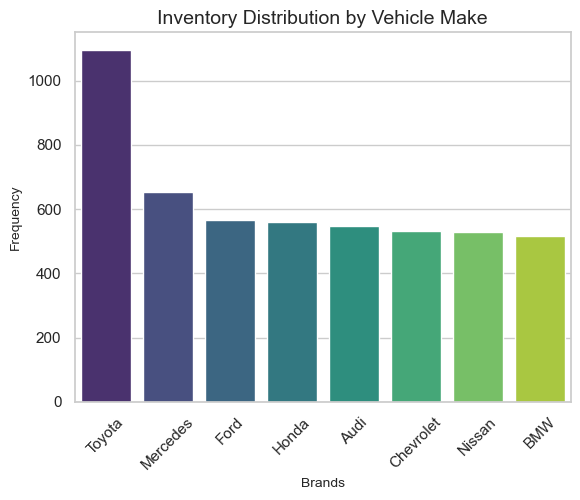



--- Vehicle Model Distribution ---
         Count  Percentage (%)
Model                         
F-150      652           13.04
Camry      637           12.74
Civic      634           12.68
Impala     632           12.64
A3         629           12.58
Corolla    620           12.40
Altima     606           12.12
X5         590           11.80


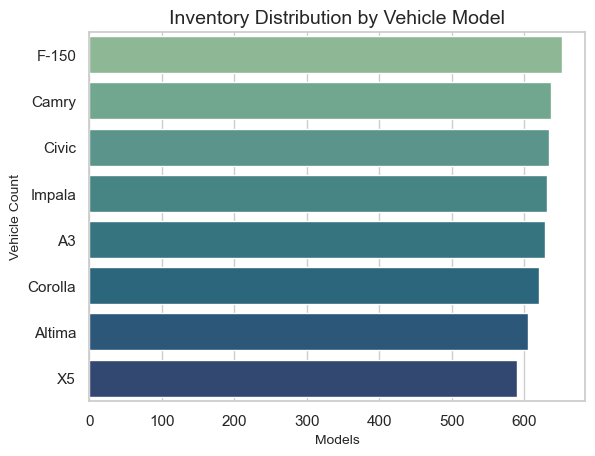

In [10]:
# Categorical Distribution (Make & Model)

# 1. Make
make_dist = pd.DataFrame({
    'Count': df['Make'].value_counts(),
    'Percentage (%)': (df['Make'].value_counts(normalize = True) * 100) 
})         

print("--- Vehicle Make Distribution ---")
print(make_dist)

# Plot
sns.countplot(data = df, x = 'Make', order = df['Make'].value_counts().index, palette = 'viridis')
plt.title("Inventory Distribution by Vehicle Make") 
plt.xlabel("Brands")
plt.ylabel("Frequency") 
plt.xticks(rotation = 45)
plt.show()

print('\n') 

# 2. Model
model_dist = pd.DataFrame({
    'Count':df['Model'].value_counts(),
    'Percentage (%)': (df['Model'].value_counts(normalize = True)* 100)
})  

print("--- Vehicle Model Distribution ---")
print(model_dist) 

# Plot
sns.countplot(data = df, y = 'Model', order = df['Model'].value_counts().index, palette = 'crest')
plt.title("Inventory Distribution by Vehicle Model")
plt.xlabel("Models")
plt.ylabel("Vehicle Count")
plt.show()

# Categorical Attribute Distribution Interpretation

The univariate analysis of the categorical features (Make and Model) highlights the volume distribution across the portfolio and exposes the 
structural anomaly introduced by the preserved Mercedes subset:

1. **Dominant Brand Share ('Make'):** The inventory is heavily led by Toyota, exceeding 1,000 units, followed by Mercedes as the second-highest 
     volume brand at 653 units. The remaining manufacturers (Ford, Honda, Audi, Chevrolet, Nissan, and BMW) maintain a highly uniform baseline, 
     clustered closely between 500 and 600 units each.
2. **Artificially Flat Model Distribution ('Model'):** The vehicle models exhibit a surprisingly flat, tightly bounded distribution each hovering 
     between roughly 580 and 650 total units. This uniform behavior across models (like the F-150, Camry, Civic, and Corolla) is directly influenced 
     by the data scramble documented in data cleaning. 

**Key Insight:**

It should be noted that the 653 Mercedes records retained their original mixed model designations (e.g. carrying model names like Camry or Corolla), 
they have artificially inflated the individual model counts while lowering the true parent brand counts for the other manufacturers. 
This visual cross-examination proves that 'Make' is the only pure representation of brand volume in this dataset, while 'Model' metrics must be
interpreted with the structural exception in mind.

In [11]:
# Numerical Distribution (Mileage & Year)
print("--- Numerical Attributes Summary Stats ---")
print(df[['Mileage', 'Year']].describe().round(2))

--- Numerical Attributes Summary Stats ---
         Mileage     Year
count    5000.00  5000.00
mean   156409.29  2012.59
std     84188.54     7.45
min     10118.00  2000.00
25%     83426.25  2006.00
50%    156432.50  2013.00
75%    231102.75  2019.00
max    299892.00  2025.00


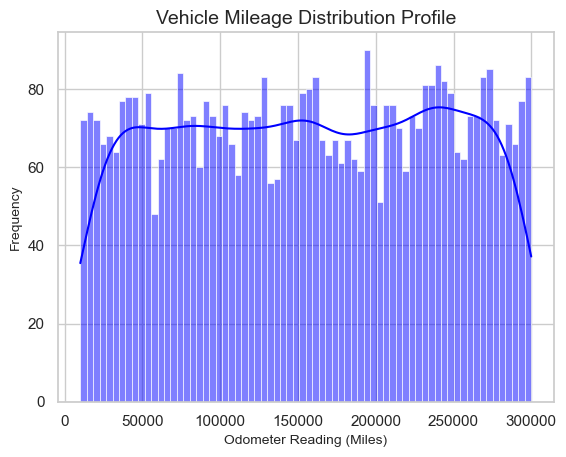

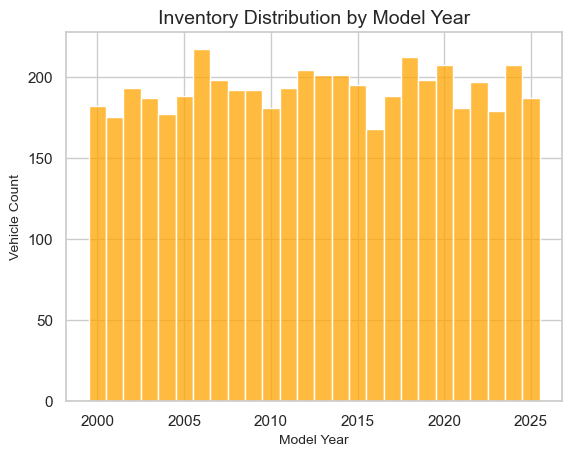

In [12]:
# Plot
# Histogram plot for Mileage
n = len(df)
mileage_bins = int(np.sqrt(n))

sns.histplot(df['Mileage'], kde = True, color = 'blue', bins = mileage_bins)
plt.title("Vehicle Mileage Distribution Profile")
plt.xlabel("Odometer Reading (Miles)")
plt.ylabel("Frequency")
plt.show() 

# Year Distribution
sns.histplot(df['Year'], color = 'orange', discrete = True)
plt.title("Inventory Distribution by Model Year")
plt.xlabel("Model Year")
plt.ylabel("Vehicle Count")
plt.show() 

# Numerical Attribute Distribution Interpretation

The univariate analysis of the numerical features (Mileage and Year) reveals a highly structured, synthetic-like profile across the dataset:

1. **Uniform Mileage Distribution:** The 'Vehicle Mileage Distribution Profile' shows a bounded uniform spread between approximately 10,000 
     and 300,000 miles. The frequency remains consistently flat between 60 and 80 counts per bin across the entire spectrum, with no distinct peak. 
     The smooth Kernel Density Estimate (KDE) line confirms the lack of a traditional Gaussian (normal) bell curve, indicating that high-mileage 
     vehicles are just as heavily represented in this inventory as low-mileage ones.
2. **Equally Distributed Model Years:** The 'Inventory Distribution by Model Year' replicates this uniform behavior. Every single model year from 
     2000 to 2025 maintains a tight, stable volume ceiling hovering consistently between 170 and 220 vehicles. There are no historical macroeconomic
     anomalies present (such as drop-offs in older inventory or spikes in newer years), signaling a completely balanced asset age distribution across
     the last quarter-century.

**Analytical Implication for Bivariate Analysis:**

Because both features are uniformly distributed across wide ranges, we have an ideal baseline to test for true continuous correlations. In the 
upcoming Bivariate phase, we can confidently analyze how 'Mileage' acts as a function of 'Model Year' without worrying about severe data scarcity
or cluster imbalances in specific years or mileage brackets.

# Bivariate Analysis 

<Axes: xlabel='Year', ylabel='Mileage'>

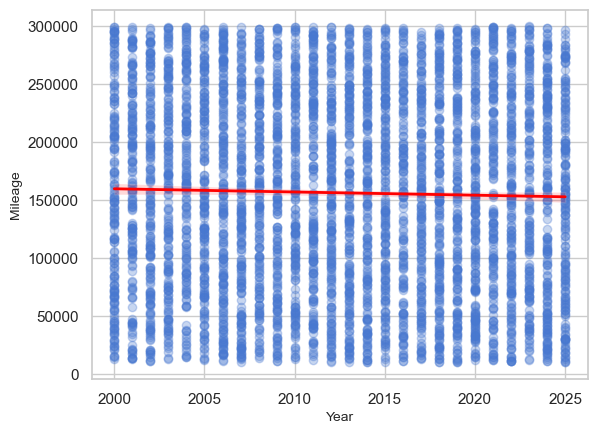

In [25]:
# 1. Continuous trend i.e Year vs. Mileage 
df.groupby("Year")["Mileage"].describe().sort_values(by = "mean", ascending = False).round(2)

# Plot
sns.regplot(
    data = df, 
    x = "Year", 
    y = "Mileage", 
    scatter_kws = {"alpha":0.3}, line_kws={'color': 'red', 'linewidth': 2}
) 

------- Summary Stats of Mileage vs. Fuel Type -------
Fuel Type     Diesel   Electric   Gasoline     Hybrid
count        1255.00    1195.00    1297.00    1253.00
mean       156133.57  158483.31  156786.67  154316.82
median     155842.00  158212.00  156680.00  154704.00
std         84509.22   83003.93   85187.78   83996.92


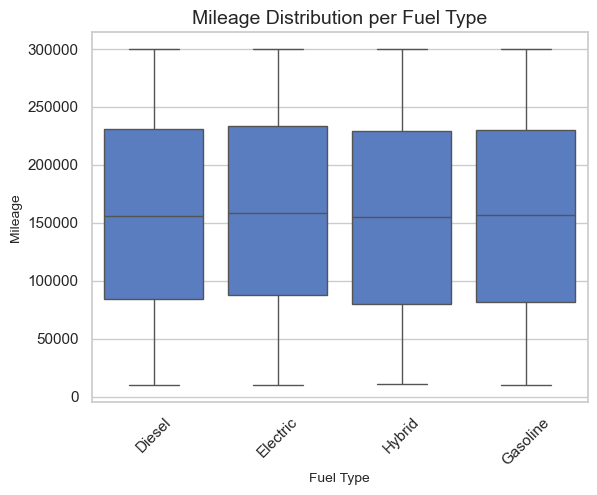



------- Summary Stats of Transmission vs. Mileage -------
              count       mean    median       std
Transmission                                      
Automatic      2483  155851.28  155544.0  83737.31
Manual         2517  156959.77  157285.0  84644.35


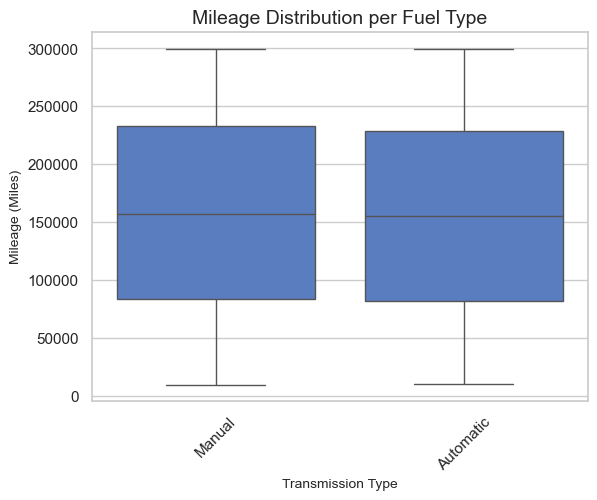



------------------- Summary Stats of Make vs. Year ---------------------
            count     mean   std     min     25%     50%     75%     max
Make                                                                    
Audi        547.0  2013.00  7.56  2000.0  2007.0  2013.0  2020.0  2025.0
BMW         517.0  2012.66  7.22  2000.0  2007.0  2012.0  2019.0  2025.0
Chevrolet   532.0  2012.53  7.64  2000.0  2006.0  2012.0  2019.0  2025.0
Ford        566.0  2012.20  7.17  2000.0  2006.0  2012.0  2018.0  2025.0
Honda       559.0  2012.76  7.47  2000.0  2007.0  2013.0  2019.0  2025.0
Mercedes    653.0  2012.49  7.40  2000.0  2006.0  2013.0  2019.0  2025.0
Nissan      530.0  2012.80  7.49  2000.0  2006.0  2013.0  2019.0  2025.0
Toyota     1096.0  2012.46  7.55  2000.0  2006.0  2012.0  2019.0  2025.0


In [38]:
# 2. Operational profile
# A. Fuel Type vs. Mileage 
print("------- Summary Stats of Mileage vs. Fuel Type -------")
print(df.groupby("Fuel Type")["Mileage"].agg(["count","mean","median","std"]).round(2).T)

# Plot
sns.boxplot(
    data = df,
    x = "Fuel Type",
    y = "Mileage",
)
plt.title("Mileage Distribution per Fuel Type")
plt.xticks(rotation = 45)
plt.show() 

print('\n') 
    
# B. Transmission vs. Mileage
print("------- Summary Stats of Transmission vs. Mileage -------")    
print(df.groupby("Transmission")["Mileage"].agg(["count","mean","median","std"]).round(2)) 

# Plot
sns.boxplot(
    data = df,
    x = "Transmission",
    y = "Mileage",
)
plt.title("Mileage Distribution per Fuel Type")
plt.xlabel("Transmission Type")
plt.ylabel("Mileage (Miles)") 
plt.xticks(rotation = 45)
plt.show()

print('\n') 

# 3. Inventory age profile
# Make vs. Year
print("------------------- Summary Stats of Make vs. Year ---------------------")        
print(df.groupby("Make")["Year"].describe().round(2))       

# Summary of Feature Independence


1. **Vehicle Make vs. Model Year**
   
Cross-examining the production year across individual vehicle brands reveals a highly structured, balanced distribution across the inventory:

- **Balanced Median Split:** The eight brands split perfectly into two balanced chronological groups. Four brands exhibit a median production
    year of  2012, while the remaining four brands show a median of 2013. 
- **Uniform Interquartile Ranges:** The middle 50% of inventory for all manufacturers occupies the exact same age bracket (spanning roughly 2006
    to 2019). No single brand skews exclusively toward legacy models or modern inventory.
  
2. **Model Year vs. Vehicle Mileage**
   
The scatter plot cross-examining vehicle year against mileage reveals that a car's age has zero impact on its odometer reading:

- **Vertical Striping Pattern:** The data points form perfectly straight, parallel vertical columns for each year from 2000 to 2025. Each column
    spans the entire mileage range uniformly from 10,000 to 300,000 miles. A 2025 model is just as likely to have high mileage as a 2000 model.
- **Horizontal Regression Line:** The red trendline sits almost perfectly flat right through the center of the data at approximately 155,000 miles.
    This visual proof confirms there is no correlation between the two variables, showing they operate independently in this dataset.
  
3. **Mileage Profiles by Fuel Type and Transmission**
   
Analyzing how mileage is distributed across categorical features reveals that mechanical differences do not alter vehicle wear:

- **Identical Mileage Averages:** The average (mean) and middle values (median) for all fuel types (Diesel, Electric, Hybrid, Gasoline)
    and transmission types (Automatic, Manual) are virtually identical, staying right around 155,000 to 157,000 miles.
- **Consistent Data Spread:** The standard deviation remains stable at roughly 83,000 to 85,000 miles across all groups. This indicates that
    the spread from low-mileage to high-mileage cars is completely mirrored across every single category.

**Analytical Conclusion**

Because these tables and plots show almost completely identical averages and ranges across different categories, these columns do not have a strong statistical relationship with each other. They operate as independent variables within this dataset.
It is therefore seen that these distributions are perfectly uniform and mirror each other identically across all categories, further bivariate plotting
of these specific feature combinations yields no additional visual insights. The dimensions act as entirely independent variables.

# Summary of Findings: EDA Report Conclusions

This Exploratory Data Analysis (EDA) evaluated an inventory dataset of 5,000 vehicle records across eight distinct manufacturers to map out structural
relationships and data integrity. 

**Key Findings** 
    
1. **Univariate Profile:** The dataset exhibits a uniform distribution across its core attributes. Model years span neatly from 2000 to 2025, and 
     odometer readings are evenly distributed between 10,000 and 300,000 miles.
2. **Absolute Feature Independence:** Bivariate cross-examinations confirm that the primary variables are statistically decoupled. 
   * Vehicle age ('Year') has zero correlation with wear ('Mileage'), as demonstrated by a completely flat regression line.
   * Central tendencies (mean and median) and data dispersion (standard deviation) remain virtually identical across all categorical slices, including
    'Fuel Type' and 'Transmission'.
3. **Data Architecture Signal:** The geometric uniformity and lack of real-world categorical correlations across the 5,000 records indicate that this 
     dataset functions as a synthetically generated or randomized matrix.

In conclusion, all major feature distributions, cross-tabulations, and visual validations have been executed and documented. This notebook serves as a
complete, self-contained Exploratory Data Analysis report confirming total feature independence across the asset inventory. 